In [1]:
import geopandas as gpd

In [5]:
# Load PVA data
pva = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/GeoPackage/Data/PVAv2.gpkg")


In [6]:
# Check what we have
print("Shape:", pva.shape)
print("CRS:", pva.crs)
print("Columns:", pva.columns.tolist())

Shape: (235, 8)
CRS: EPSG:27700
Columns: ['OBJECTID_1', 'PVA_Name', 'Desig_Date', 'Chng_C1', 'PVA_Ref', 'Shape_Length', 'Shape_Area', 'geometry']


In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Load PVA data
pva = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/GeoPackage/Data/PVAv2.gpkg")

# University of Strathclyde coordinates (latitude/longitude)
# Converting to EPSG:27700 (British National Grid) to match PVA data
from shapely.geometry import Point

# Strathclyde uni coordinates in British National Grid
uni_point = Point(260983, 665006)  

# Create a 5km buffer around the university
uni_buffer = uni_point.buffer(5000)  # 5000 metres = 5km

# Filter PVA zones that fall within the buffer
pva_glasgow = pva[pva.geometry.intersects(uni_buffer)]

print("Total PVA zones in Scotland:", len(pva))
print("PVA zones within 5km of Strathclyde:", len(pva_glasgow))
print(pva_glasgow[['PVA_Name', 'PVA_Ref', 'Shape_Area']])

Total PVA zones in Scotland: 235
PVA zones within 5km of Strathclyde: 7
                          PVA_Name   PVA_Ref    Shape_Area
156                   River Kelvin  02/11/04  1.859940e+08
157            Glasgow City centre  02/11/05  4.271800e+06
158             Glasgow City north  02/11/06  2.465605e+07
159         Luggie Water catchment  02/11/07  1.126656e+08
162  East of Glasgow to Strathaven  02/11/10  1.502328e+08
168                     Rutherglen  02/11/16  1.244148e+07
169     White Cart Water catchment  02/11/17  2.091868e+08


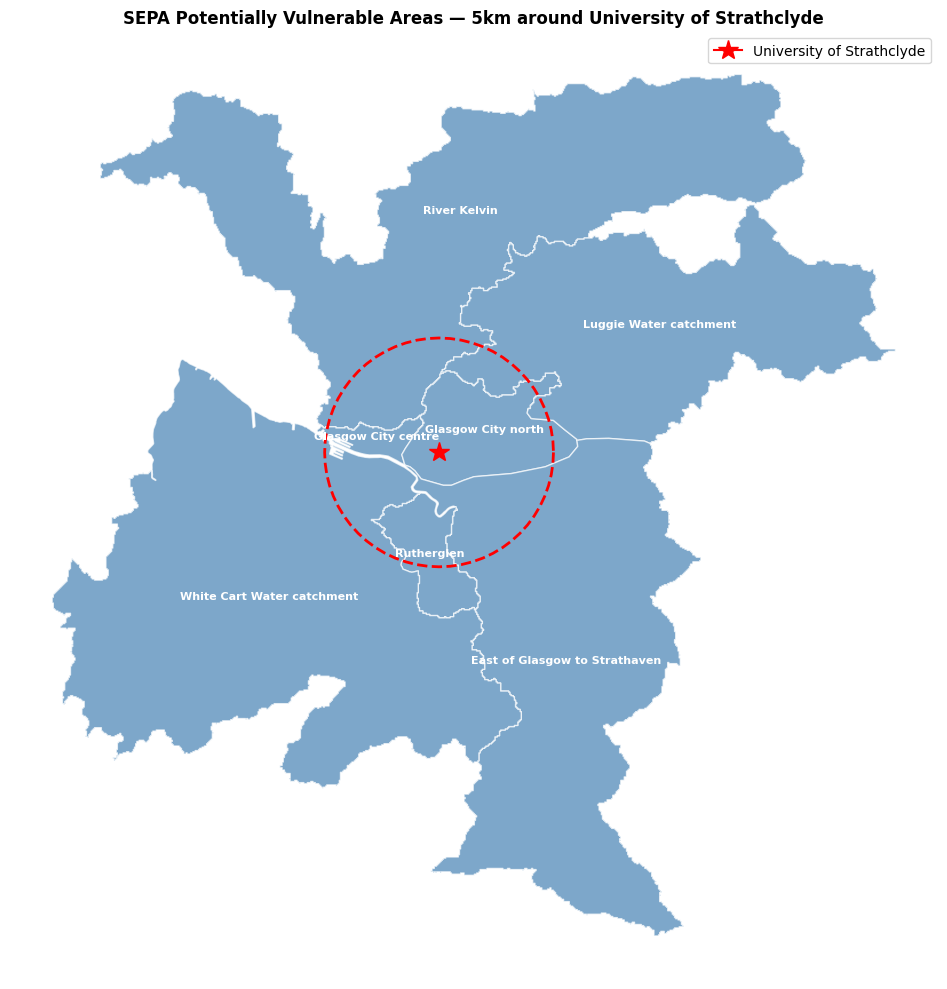

Map saved!


In [8]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Load PVA data
pva = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/GeoPackage/Data/PVAv2.gpkg")

# University point and 5km buffer
uni_point = Point(260983, 665006)
uni_buffer = gpd.GeoDataFrame(geometry=[uni_point.buffer(5000)], crs="EPSG:27700")

# Filter to 5km area
pva_glasgow = pva[pva.geometry.intersects(uni_point.buffer(5000))]

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot flood zones
pva_glasgow.plot(ax=ax, color='steelblue', edgecolor='white', alpha=0.7)

# Plot buffer circle
uni_buffer.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='--')

# Plot university point
ax.plot(260983, 665006, marker='*', color='red', markersize=15, label='University of Strathclyde')

# Add zone names
for idx, row in pva_glasgow.iterrows():
    ax.annotate(row['PVA_Name'], 
                xy=row['geometry'].centroid.coords[0],
                fontsize=8, ha='center', color='white', fontweight='bold')

ax.set_title("SEPA Potentially Vulnerable Areas — 5km around University of Strathclyde", 
             fontsize=12, fontweight='bold')
ax.axis('off')
plt.legend()
plt.tight_layout()
plt.savefig("/Users/riteshghorpade/Documents/010_Project/002_Dataset/glasgow_pva_map.png", dpi=150)
plt.show()
print("Map saved!")

In [1]:
pip install osmnx

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 101 kB 1.2 MB/s ta 0:00:01
     |████████████████████████████████| 1.6 MB 1.8 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 2.6 MB/s eta 0:00:01
     |████████████████████████████████| 65 kB 1.9 MB/s eta 0:00:01
     |████████████████████████████████| 299 kB 2.3 MB/s eta 0:00:01
     |████████████████████████████████| 131 kB 2.2 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import osmnx as ox

# Download Glasgow street network and buildings within 5km of Strathclyde
print("Downloading OSM data... this may take 1-2 minutes")

# University of Strathclyde lat/lon
lat, lon = 55.8617, -4.2438

# Download buildings
buildings = ox.features_from_point(
    (lat, lon), 
    tags={'building': True}, 
    dist=5000
)

print("Buildings downloaded:", len(buildings))
print("Columns:", buildings.columns.tolist())

/Users/riteshghorpade/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Buildings downloaded: 55638
Columns: ['geometry', 'addr:city', 'addr:county', 'addr:housenumber', 'addr:postcode', 'addr:street', 'amenity', 'brand', 'brand:wikidata', 'brand:wikipedia', 'brewery', 'building', 'changing_table', 'contact:phone', 'diet:vegan', 'diet:vegetarian', 'dog', 'fhrs:authority', 'fhrs:id', 'fhrs:local_authority_id', 'fhrs:rating', 'fhrs:rating_date', 'food', 'internet_access', 'internet_access:fee', 'name', 'note', 'opening_hours', 'payment:debit_cards', 'payment:mastercard', 'payment:visa', 'real_ale', 'source:fhrs', 'source:website', 'toilets', 'toilets:access', 'toilets:wheelchair', 'website', 'website:menu', 'wheelchair', 'operator', 'operator:wikidata', 'power', 'ref', 'substation', 'check_date', 'historic', 'phone', 'tourism', 'addr:floor', 'addr:unit', 'clothes', 'construction', 'level', 'payment:cash', 'payment:credit_cards', 'shop', 'source', 'addr:country', 'contact:website', 'fuel:diesel', 'fuel:diesel_B', 'fuel:e10', 'fuel:e5', 'fuel:gasoline', 'fuel:

In [4]:
#Data Cleaning and Preparation

In [5]:
import geopandas as gpd
from shapely.geometry import Point

# Keep only useful columns for flood risk
buildings_clean = buildings[['geometry', 'building', 'building:levels', 'height', 'name']].copy()

# Make sure CRS matches your SEPA data (EPSG:27700)
buildings_clean = buildings_clean.to_crs("EPSG:27700")

print("Buildings cleaned shape:", buildings_clean.shape)
print("CRS:", buildings_clean.crs)

# Save to your dataset folder
buildings_clean.to_file(
    "/Users/riteshghorpade/Documents/010_Project/002_Dataset/osm_buildings_glasgow.gpkg",
    driver="GPKG"
)
print("Buildings saved!")

Buildings cleaned shape: (55638, 5)
CRS: EPSG:27700
Buildings saved!


In [9]:
# Download roads within 5km of Strathclyde
print("Downloading roads...")
roads = ox.features_from_point(
    (lat, lon),
    tags={'highway': True},
    dist=5000
)

# Keep useful columns only
roads_clean = roads[['geometry', 'highway', 'name']].copy()
roads_clean = roads_clean.to_crs("EPSG:27700")
print("Roads downloaded:", len(roads_clean))

# Download water bodies
print("Downloading water bodies...")
water = ox.features_from_point(
    (lat, lon),
    tags={'natural': 'water'},
    dist=5000
)

# Keep useful columns only
water_clean = water[['geometry', 'name']].copy()
water_clean = water_clean.to_crs("EPSG:27700")
print("Water bodies downloaded:", len(water_clean))

# Save both
roads_clean.to_file(
    "/Users/riteshghorpade/Documents/010_Project/002_Dataset/osm_roads_glasgow.gpkg",
    driver="GPKG"
)

water_clean.to_file(
    "/Users/riteshghorpade/Documents/010_Project/002_Dataset/osm_water_glasgow.gpkg",
    driver="GPKG"
)

print("Roads and water saved!")

Roads downloaded: 38218
Water bodies downloaded: 195
Roads and water saved!


/var/folders/1t/s4nhjjr55y7cv2zhjd_7k0q40000gn/T/ipykernel_5032/2186097322.py:42: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower right')


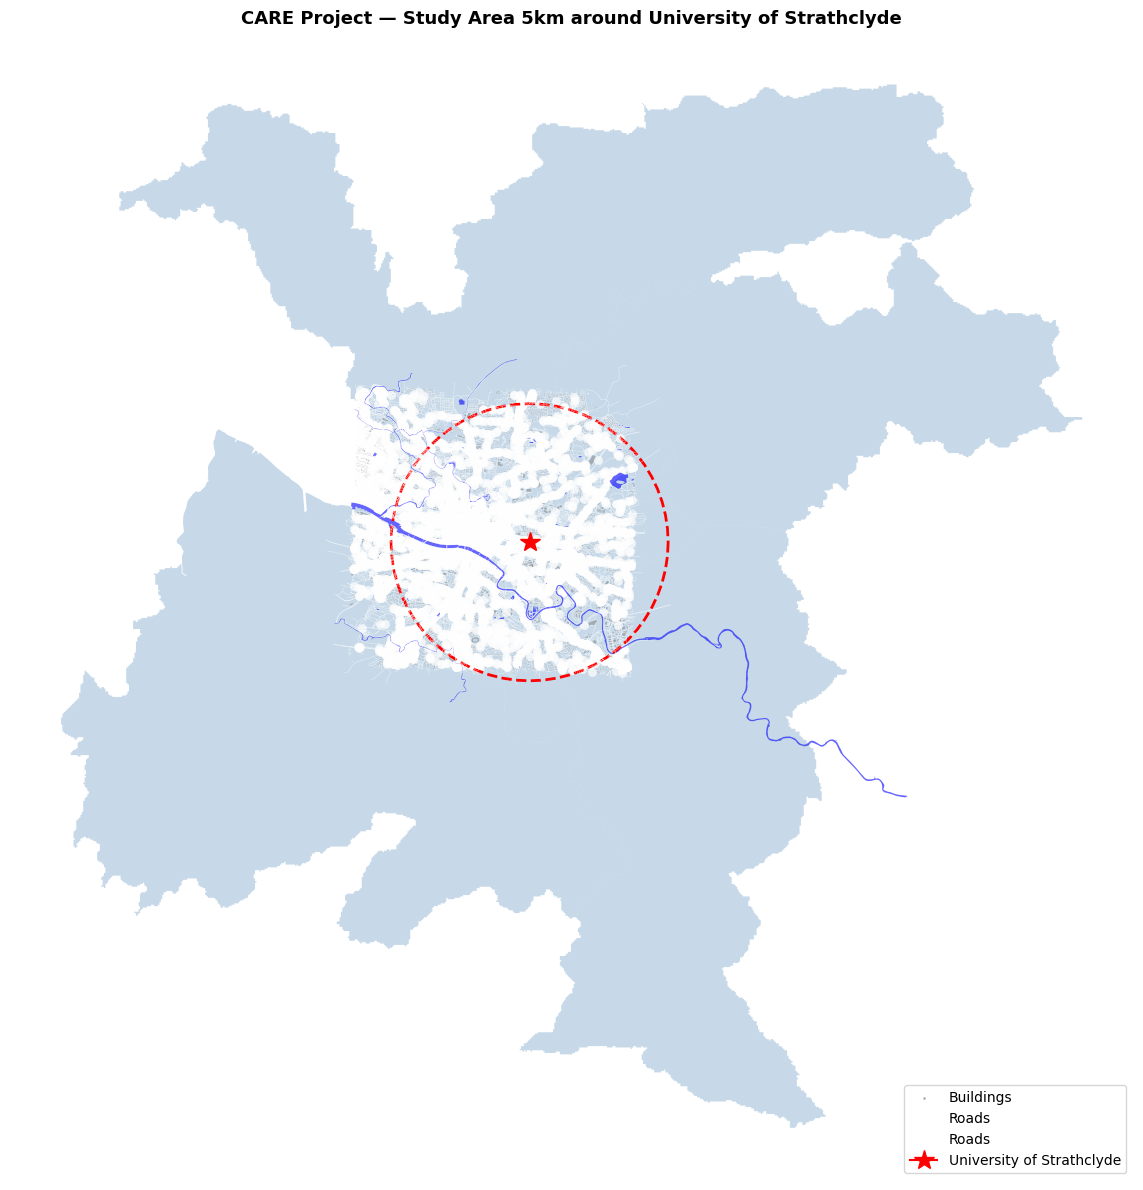

Map saved!


In [17]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point

# Reload PVA data - correct path
pva = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/GeoPackage/Data/PVAv2.gpkg")

# University point and buffer
uni_point = Point(260983, 665006)
uni_buffer = gpd.GeoDataFrame(geometry=[uni_point.buffer(5000)], crs="EPSG:27700")

# Load saved files
pva_glasgow = pva[pva.geometry.intersects(uni_point.buffer(5000))]
buildings_clean = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/osm_buildings_glasgow.gpkg")
roads_clean = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/osm_roads_glasgow.gpkg")
water_clean = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/osm_water_glasgow.gpkg")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 12))

# Layer 1 - Flood zones
pva_glasgow.plot(ax=ax, color='steelblue', alpha=0.3, label='Flood zones')

# Layer 2 - Buildings
buildings_clean.plot(ax=ax, color='grey', alpha=0.5, markersize=1, label='Buildings')

# Layer 3 - Roads
roads_clean.plot(ax=ax, color='white', linewidth=0.3, alpha=0.7, label='Roads')

# Layer 4 - Water
water_clean.plot(ax=ax, color='blue', alpha=0.6, label='Water bodies')

# Layer 5 - Study area boundary
uni_buffer.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='--')

# University point
ax.plot(260983, 665006, marker='*', color='red', markersize=15, label='University of Strathclyde')

ax.set_title("CARE Project — Study Area 5km around University of Strathclyde",
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("/Users/riteshghorpade/Documents/010_Project/002_Dataset/glasgow_full_map.png", dpi=150)
plt.show()
print("Map saved!")

In [18]:
pip install elevation rasterio

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 18.8 MB 4.0 MB/s eta 0:00:01
     |████████████████████████████████| 98 kB 33.8 MB/s eta 0:00:01
     |████████████████████████████████| 67 kB 17.7 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [19]:
import rasterio
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, box
import subprocess
import os

# Define bounding box around 5km study area (in WGS84 lat/lon)
# These coordinates cover the 5km area around University of Strathclyde
min_lon, min_lat = -4.35, 55.82
max_lon, max_lat = -4.15, 55.92

# Output path for elevation file
output_path = "/Users/riteshghorpade/Documents/010_Project/002_Dataset/glasgow_elevation.tif"

# Download elevation data using elevation library
print("Downloading elevation data...")
subprocess.run([
    "eio", "clip",
    "-o", output_path,
    "--bounds", str(min_lon), str(min_lat), str(max_lon), str(max_lat)
])

print("Elevation data downloaded!")

# Check the file
with rasterio.open(output_path) as src:
    print("CRS:", src.crs)
    print("Shape:", src.shape)
    print("Bounds:", src.bounds)

curl -s -o spool/N55/N55W005.hgt.gz.temp https://s3.amazonaws.com/elevation-tiles-prod/skadi/N55/N55W005.hgt.gz && mv spool/N55/N55W005.hgt.gz.temp spool/N55/N55W005.hgt.gz
gunzip spool/N55/N55W005.hgt.gz 2>/dev/null || touch spool/N55/N55W005.hgt
gdal_translate -q -co TILED=YES -co COMPRESS=DEFLATE -co ZLEVEL=9 -co PREDICTOR=2 spool/N55/N55W005.hgt cache/N55/N55W005.tif 2>/dev/null || touch cache/N55/N55W005.tif
rm spool/N55/N55W005.hgt
gdalbuildvrt -q -overwrite SRTM1.vrt 
Elevation data downloaded!


make: gdalbuildvrt: No such file or directory
make: *** [SRTM1.vrt] Error 1
Traceback (most recent call last):
  File "/Users/riteshghorpade/Library/Python/3.9/bin/eio", line 8, in <module>
    sys.exit(eio())
  File "/Users/riteshghorpade/Library/Python/3.9/lib/python/site-packages/click/core.py", line 1161, in __call__
    return self.main(*args, **kwargs)
  File "/Users/riteshghorpade/Library/Python/3.9/lib/python/site-packages/click/core.py", line 1082, in main
    rv = self.invoke(ctx)
  File "/Users/riteshghorpade/Library/Python/3.9/lib/python/site-packages/click/core.py", line 1697, in invoke
    return _process_result(sub_ctx.command.invoke(sub_ctx))
  File "/Users/riteshghorpade/Library/Python/3.9/lib/python/site-packages/click/core.py", line 1443, in invoke
    return ctx.invoke(self.callback, **ctx.params)
  File "/Users/riteshghorpade/Library/Python/3.9/lib/python/site-packages/click/core.py", line 788, in invoke
    return __callback(*args, **kwargs)
  File "/Users/riteshg

RasterioIOError: /Users/riteshghorpade/Documents/010_Project/002_Dataset/glasgow_elevation.tif: No such file or directory

In [21]:
import requests
import numpy as np
import geopandas as gpd
from shapely.geometry import Point
import pandas as pd

# Create a grid of points within 5km of Strathclyde
# We'll get elevation for each point

print("Creating grid of points...")

# Grid of lat/lon points covering our study area
lats = np.linspace(55.82, 55.92, 20)
lons = np.linspace(-4.35, -4.15, 20)

# Create all combinations
points = []
for lat in lats:
    for lon in lons:
        points.append({"latitude": lat, "longitude": lon})

print(f"Total points: {len(points)}")

# Query Open-Elevation API in batches
print("Fetching elevation data...")
url = "https://api.open-elevation.com/api/v1/lookup"

response = requests.post(
    url,
    json={"locations": points}
)

if response.status_code == 200:
    results = response.json()['results']
    print("Elevation data received!")
    print(f"Sample: {results[0]}")
else:
    print("Error:", response.status_code)

Creating grid of points...
Total points: 400
Fetching elevation data...
Elevation data received!
Sample: {'elevation': 21.0, 'longitude': -4.35, 'latitude': 55.82}


In [22]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Convert results to dataframe
print("Processing elevation data...")

# Extract all elevation values
elevation_df = pd.DataFrame(results)
print("Elevation dataframe shape:", elevation_df.shape)
print(elevation_df.head())

# Convert to GeoDataFrame
elevation_gdf = gpd.GeoDataFrame(
    elevation_df,
    geometry=gpd.points_from_xy(elevation_df.longitude, elevation_df.latitude),
    crs="EPSG:4326"
)

# Convert to EPSG:27700 to match other datasets
elevation_gdf = elevation_gdf.to_crs("EPSG:27700")

print("\nElevation stats:")
print("Min elevation:", elevation_df['elevation'].min(), "metres")
print("Max elevation:", elevation_df['elevation'].max(), "metres")
print("Average elevation:", round(elevation_df['elevation'].mean(), 2), "metres")

# Save to dataset folder
elevation_gdf.to_file(
    "/Users/riteshghorpade/Documents/010_Project/002_Dataset/glasgow_elevation.gpkg",
    driver="GPKG"
)

print("\nElevation data saved!")

Processing elevation data...
Elevation dataframe shape: (400, 3)
   elevation  longitude  latitude
0       21.0  -4.350000     55.82
1       17.0  -4.339474     55.82
2       23.0  -4.328947     55.82
3       41.0  -4.318421     55.82
4       33.0  -4.307895     55.82

Elevation stats:
Min elevation: 0.0 metres
Max elevation: 107.0 metres
Average elevation: 41.86 metres

Elevation data saved!


/var/folders/1t/s4nhjjr55y7cv2zhjd_7k0q40000gn/T/ipykernel_5032/2816976154.py:42: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower right')


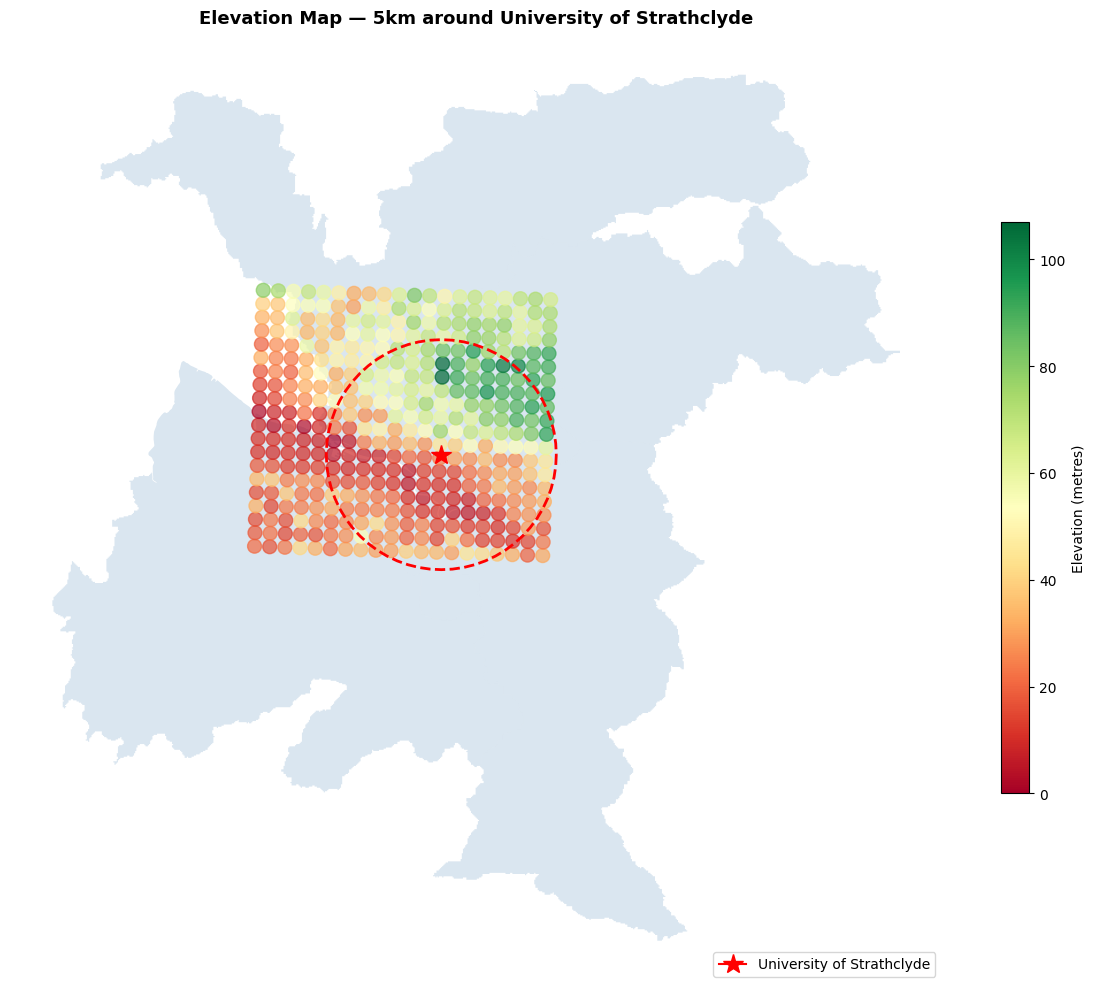

Elevation map saved!


In [23]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point

# Reload PVA data
pva = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/GeoPackage/Data/PVAv2.gpkg")
uni_point = Point(260983, 665006)
pva_glasgow = pva[pva.geometry.intersects(uni_point.buffer(5000))]
uni_buffer = gpd.GeoDataFrame(geometry=[uni_point.buffer(5000)], crs="EPSG:27700")

# Reload elevation data
elevation_gdf = gpd.read_file("/Users/riteshghorpade/Documents/010_Project/002_Dataset/glasgow_elevation.gpkg")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Plot flood zones as background
pva_glasgow.plot(ax=ax, color='steelblue', alpha=0.2, label='Flood zones')

# Plot elevation points as coloured dots
elevation_gdf.plot(
    ax=ax,
    column='elevation',
    cmap='RdYlGn',
    markersize=100,
    alpha=0.7,
    legend=True,
    legend_kwds={'label': 'Elevation (metres)', 'shrink': 0.6}
)

# Study area boundary
uni_buffer.plot(ax=ax, color='none', edgecolor='red', linewidth=2, linestyle='--')

# University point
ax.plot(260983, 665006, marker='*', color='red', markersize=15, label='University of Strathclyde')

ax.set_title("Elevation Map — 5km around University of Strathclyde", 
             fontsize=13, fontweight='bold')
ax.axis('off')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("/Users/riteshghorpade/Documents/010_Project/002_Dataset/glasgow_elevation_map.png", dpi=150)
plt.show()
print("Elevation map saved!")